In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
import warnings
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
warnings.filterwarnings("ignore")

<h1>Data Preprocessing: Cleaning, Tokenization, and Vectorization</h1>

In [3]:
news_data_df = pd.read_csv('data/news_category.csv')

In [4]:
news_data_df

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
...,...,...
11020,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH
11021,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS
11022,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS
11023,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS


In [5]:
news_data_df['headline'][0]

'How A New Documentary Captures The Complexity Of Being A Child Of Immigrants'

In [6]:
news_data_df['category'].value_counts()

category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64

In [7]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to C:\Users\Prince
[nltk_data]     Awale\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Prince
[nltk_data]     Awale\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Prince
[nltk_data]     Awale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
stop_words_set = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [9]:
def clean_text_data(raw_input):
    raw_input = raw_input.lower()

    # Expand contractions
    raw_input = contractions.fix(raw_input)

    # Remove URLs
    raw_input = re.sub(r'https?://\S+|www\.\S+', '', raw_input)

    # Remove mentions and hashtags
    raw_input = re.sub(r'@\w+|#\w+', '', raw_input)

    # Remove numbers
    raw_input = re.sub(r'\d+', '', raw_input)

    # Remove punctuation
    raw_input = raw_input.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = raw_input.split()

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words_set
    ]

    return " ".join(tokens)

In [10]:
clean_text_data("How A New Documentary Captures The Complexity Of Being A Child Of Immigrants")

'new documentary capture complexity child immigrant'

In [11]:
news_data_df['processed_headline'] = news_data_df['headline'].apply(clean_text_data)

In [12]:
def generate_word_cloud(docs):
    combined_text = " ".join(docs)

    cloud_generator = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(combined_text)

    plt.figure()
    plt.imshow(cloud_generator)
    plt.axis("off")
    plt.title("Word Cloud")
    plt.show()

In [13]:
news_data_df['processed_headline']

0        new documentary capture complexity child immig...
1              twitch ban gambling site streamer scam folk
2          reboot clever navelgazey look inside tv reboots
3              maury will basestealing shortstop dodger dy
4        la vega ace win first wnba title chelsea gray ...
                               ...                        
11020    rim ceo thorsten heins significant plan blackb...
11021    maria sharapova stunned victoria azarenka aust...
11022    giant patriot jet colt among improbable super ...
11023        aldon smith arrested er linebacker busted duo
11024         dwight howard rip teammate magic loss hornet
Name: processed_headline, Length: 11025, dtype: str

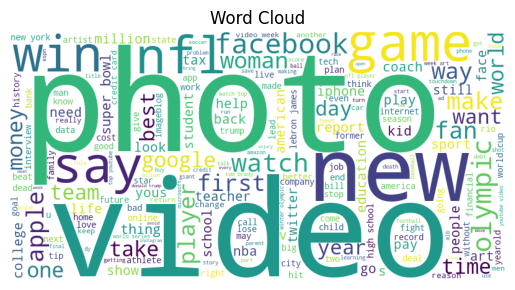

In [14]:
generate_word_cloud(news_data_df['processed_headline'])

In [15]:
# Split data into train and test sets
train_docs, test_docs = train_test_split(
    news_data_df['processed_headline'],
    test_size=0.2,
    random_state=42
)

In [16]:
# Get category labels corresponding to data split
train_indices, test_indices = train_test_split(
    range(len(news_data_df)),
    test_size=0.2,
    random_state=42
)

train_labels = news_data_df.iloc[train_indices]['category'].values
test_labels = news_data_df.iloc[test_indices]['category'].values

# Encode category labels to integers
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Convert to one-hot encoding
train_y = to_categorical(train_labels_encoded, num_classes=5)
test_y = to_categorical(test_labels_encoded, num_classes=5)

print("train_y shape:", train_y.shape)
print("test_y shape:", test_y.shape)

train_y shape: (8820, 5)
test_y shape: (2205, 5)


In [17]:
# Create word-to-index mapping
vocab_max_size = 20000  

text_tokenizer = Tokenizer(num_words=vocab_max_size, oov_token="<OOV>")
text_tokenizer.fit_on_texts(train_docs)

# Convert texts to sequences
train_token_seqs = text_tokenizer.texts_to_sequences(train_docs)
test_token_seqs = text_tokenizer.texts_to_sequences(test_docs)

In [18]:
seq_lengths = [len(seq) for seq in train_token_seqs]

# Set max length at 95th percentile
max_length = int(np.percentile(seq_lengths, 95))

print("Selected max_length:", max_length)

Selected max_length: 11


In [19]:
train_padded = pad_sequences(
    train_token_seqs,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

test_padded = pad_sequences(
    test_token_seqs,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

<h1>Model Construction and Configuration</h1>

In [20]:
vocab_max_size = 20000
embed_dim = 128
num_classes = 5

<h1>RNN Model Implementation</h1>

In [21]:
rnn_model = Sequential()

rnn_model.add(Embedding(
    input_dim=vocab_max_size,
    output_dim=embed_dim,
    input_length=max_length
))

# Two RNN layers with dropout to reduce overfitting
rnn_model.add(SimpleRNN(64, return_sequences=True))
rnn_model.add(Dropout(0.4))

rnn_model.add(SimpleRNN(32))
rnn_model.add(Dropout(0.4))

# Output classification layer
rnn_model.add(Dense(64, activation='relu'))
rnn_model.add(Dropout(0.5))

rnn_model.add(Dense(num_classes, activation='softmax'))

In [22]:
rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

<h1>LSTM Model Architecture</h1>

In [23]:
lstm_model = Sequential()

lstm_model.add(Embedding(
    input_dim=vocab_max_size,
    output_dim=embed_dim,
    input_length=max_length
))

# Two LSTM layers with dropout to reduce overfitting
lstm_model.add(LSTM(64, return_sequences=True)) 
lstm_model.add(Dropout(0.4))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.4))

# Output classification layer
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(num_classes, activation='softmax'))

In [24]:
lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

<h1>LSTM with Pre-trained GloVe Embeddings</h1>

In [25]:
pretrained_embeddings = {}

with open("data/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        coefficients = np.asarray(parts[1:], dtype='float32')
        pretrained_embeddings[word] = coefficients

In [26]:
embedding_dim_glove = 100

embedding_matrix = np.zeros((vocab_max_size, embedding_dim_glove))

for word, idx in text_tokenizer.word_index.items():
    if idx >= vocab_max_size:
        continue
    embedding_vector = pretrained_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector

In [27]:
lstm_glove_model = Sequential()

lstm_glove_model.add(Embedding(
    input_dim=vocab_max_size,
    output_dim=embedding_dim_glove,
    weights=[embedding_matrix],
    input_length=max_length,
    trainable=False,
    mask_zero=True
))

# Two LSTM layers with dropout to reduce overfitting
lstm_glove_model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
lstm_glove_model.add(Dropout(0.4))

lstm_glove_model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
lstm_glove_model.add(Dropout(0.4))

# Dense layers for classification
lstm_glove_model.add(Dense(128, activation='relu'))
lstm_glove_model.add(Dropout(0.5))

lstm_glove_model.add(Dense(num_classes, activation='softmax'))

lstm_glove_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

<h1>Model Training and Validation</h1>

In [28]:
rnn_checkpoint = ModelCheckpoint(
    "best_rnn.h5",
    monitor='val_loss',
    save_best_only=True
)

lstm_checkpoint = ModelCheckpoint(
    "best_lstmm.h5",
    monitor='val_loss',
    save_best_only=True
)

glove_checkpoint = ModelCheckpoint(
    "best_lstm_w2v.h5",
    monitor="val_loss",
    save_best_only=True
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [29]:
history_lstm = lstm_model.fit(
    train_padded,
    train_y,
    validation_split=0.1,
    epochs=20,
    batch_size=16,
    callbacks=[lstm_checkpoint, early_stopping]
)

Epoch 1/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4979 - loss: 1.2423

497/497 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.5651 - loss: 1.0548 - val_accuracy: 0.6689 - val_loss: 0.7868
Epoch 2/20
496/497 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7082 - loss: 0.6455

497/497 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7537 - loss: 0.5897 - val_accuracy: 0.7472 - val_loss: 0.6185
Epoch 3/20
496/497 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8769 - loss: 0.3337

497/497 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8888 - loss: 0.3212 - val_accuracy: 0.8163 - val_loss: 0.5664
Epoch 4/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9563 - loss: 0.1710 - val_accuracy: 0.8299 - val_loss: 0.6756
Epoch 5/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9769 - loss: 0.1025 - val_accuracy: 0.8299 - val_loss: 0.6806
Epoch 6/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9865 - loss: 0.0668 - val_accuracy: 0.8311 - val_loss: 0.8906
Epoch 7/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9917 - loss: 0.0442 - val_accuracy: 0.8288 - val_loss: 1.0281
Epoch 8/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9904 - loss: 0.0444 - val_accuracy: 0.8186 - val_loss: 0.9954
Epoch 9/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9922 - loss: 0.0417 - val_accuracy: 0.8129 - val_loss: 0.9504
Epoch 10/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9953 - loss: 0.0251 - val_accura

In [30]:
history_glove = lstm_glove_model.fit(
    train_padded,
    train_y,
    validation_split = 0.1,
    epochs=30,
    batch_size=16,
    callbacks=[glove_checkpoint, early_stopping]
)

Epoch 1/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6183 - loss: 1.0158

497/497 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.7208 - loss: 0.7942 - val_accuracy: 0.8095 - val_loss: 0.5226
Epoch 2/30
495/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8170 - loss: 0.5589

497/497 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8162 - loss: 0.5565 - val_accuracy: 0.8288 - val_loss: 0.4776
Epoch 3/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8313 - loss: 0.5101

497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8348 - loss: 0.5031 - val_accuracy: 0.8390 - val_loss: 0.4664
Epoch 4/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8561 - loss: 0.4400

497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8488 - loss: 0.4580 - val_accuracy: 0.8390 - val_loss: 0.4625
Epoch 5/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8641 - loss: 0.4236

497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8624 - loss: 0.4220 - val_accuracy: 0.8560 - val_loss: 0.4249
Epoch 6/30
495/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8708 - loss: 0.3950

497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8662 - loss: 0.4069 - val_accuracy: 0.8662 - val_loss: 0.4105
Epoch 7/30
495/497 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8829 - loss: 0.3664

497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8788 - loss: 0.3768 - val_accuracy: 0.8662 - val_loss: 0.4019
Epoch 8/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8838 - loss: 0.3566 - val_accuracy: 0.8605 - val_loss: 0.4181
Epoch 9/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8920 - loss: 0.3355 - val_accuracy: 0.8617 - val_loss: 0.4075
Epoch 10/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8937 - loss: 0.3174 - val_accuracy: 0.8617 - val_loss: 0.4490
Epoch 11/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9022 - loss: 0.2917 - val_accuracy: 0.8719 - val_loss: 0.4280
Epoch 12/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9104 - loss: 0.2736 - val_accuracy: 0.8719 - val_loss: 0.4331
Epoch 13/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9077 - loss: 0.2679 - val_accuracy: 0.8685 - val_loss: 0.4293
Epoch 14/30
497/497 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9200 - loss: 0.2490 - val_accuracy: 

In [ ]:
history_rnn = rnn_model.fit(
    train_padded,
    train_y,
    validation_split=0.1,
    epochs=20,
    batch_size=16,
    callbacks=[rnn_checkpoint, early_stopping]
)

Epoch 1/20
496/497 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4317 - loss: 1.3649

497/497 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.5232 - loss: 1.1815 - val_accuracy: 0.6599 - val_loss: 0.9226
Epoch 2/20
496/497 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6921 - loss: 0.7853

497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7250 - loss: 0.7259 - val_accuracy: 0.7188 - val_loss: 0.7823
Epoch 3/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8506 - loss: 0.4259 - val_accuracy: 0.7619 - val_loss: 0.8241
Epoch 4/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9116 - loss: 0.2809 - val_accuracy: 0.7937 - val_loss: 0.8842
Epoch 5/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9539 - loss: 0.1603 - val_accuracy: 0.8005 - val_loss: 1.0208
Epoch 6/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9694 - loss: 0.1268 - val_accuracy: 0.7846 - val_loss: 1.1206
Epoch 7/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9777 - loss: 0.0860 - val_accuracy: 0.7868 - val_loss: 1.1424
Epoch 8/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9815 - loss: 0.0717 - val_accuracy: 0.7653 - val_loss: 1.3914
Epoch 9/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9767 - loss: 0.0862 - val_accurac

<h1>Model Evaluation and Results Visualization</h1>

In [ ]:
def plot_training_metrics(history, model_type):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'])
    axes[0].plot(history.history['val_accuracy'])
    axes[0].set_title(f'{model_type} Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(['Train', 'Validation'])

    # Loss chart
    axes[1].plot(history.history['loss'])
    axes[1].plot(history.history['val_loss'])
    axes[1].set_title(f'{model_type} Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_metrics(history_rnn, "RNN")
plot_training_metrics(history_lstm, "LSTM")
plot_training_metrics(history_glove, "LSTM + GloVe")

In [ ]:
rnn_acc = rnn_model.evaluate(test_padded, test_y, verbose=0)[1]
lstm_acc = lstm_model.evaluate(test_padded, test_y, verbose=0)[1]
glove_acc = lstm_glove_model.evaluate(test_padded, test_y, verbose=0)[1]

print(f"RNN Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print(f"LSTM + GloVe Accuracy: {glove_acc:.4f}")

In [ ]:
for model, model_label in [(rnn_model, "RNN"), (lstm_model, "LSTM"), (lstm_glove_model, "LSTM + GloVe")]:
    preds = model.predict(test_padded)
    pred_classes = np.argmax(preds, axis=1)
    cm = confusion_matrix(test_labels_encoded, pred_classes)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {model_label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

<h1>Error Analysis and Classification Insights</h1>

In [ ]:
error_sample_indices = np.where(pred_classes != test_labels_encoded)[0]

print("\n" + "="*60)
print("ERROR ANALYSIS: Sample Misclassified Cases")
print("="*60)

for case_num, case_idx in enumerate(error_sample_indices[:3], 1):
    print(f"\nCase {case_num}:")
    print(f"  Text: {test_docs.iloc[case_idx][:100]}...")
    print(f"  True Label: {label_encoder.classes_[test_labels_encoded[case_idx]]}")
    print(f"  Predicted: {label_encoder.classes_[pred_classes[case_idx]]}")
    print(f"  Score: {np.max(preds[case_idx]):.4f}")
    print("-" * 60)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_labels_encoded, pred_classes, target_names=label_encoder.classes_))